In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support,precision_recall_curve, auc,roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import label_binarize


In [ ]:
# Daten laden
train_df = pd.read_csv('features_train_simple.csv')
val_df = pd.read_csv('features_val_simple.csv')
test_df = pd.read_csv('features_test_simple.csv')

# Features + Labels trennen
X_train = train_df.drop(['label_id', 'label'], axis=1).values
y_train = train_df['label_id'].values
X_val = val_df.drop(['label_id', 'label'], axis=1).values
y_val = val_df['label_id'].values
X_test = test_df.drop(['label_id', 'label'], axis=1).values
y_test = test_df['label_id'].values

# Normalisierung (für SVM/KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)      # LERNT
X_val_scaled = scaler.transform(X_val)              # ANWENDEN
X_test_scaled = scaler.transform(X_test)            # ANWENDEN


print(f"Features: {X_train.shape[1]}, Klassen: {len(np.unique(y_train))}")


In [ ]:
feature_names = train_df.drop(['label_id', 'label'], axis=1).columns
print(feature_names)

In [ ]:
label_names = sorted(train_df['label'].unique())
print(label_names)

In [ ]:
label_mapping = dict(enumerate(sorted(train_df['label'].unique())))
print(label_mapping)


In [ ]:
# Baseline Modelle (Standardparameter)
models_baseline = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

print("Baseline Performance (5-Fold CV auf Train):")
baseline_results = {}
for name, model in models_baseline.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    baseline_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")


In [ ]:
# HYPERPARAMETER GRIDS 
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.001, 0.01],
        'kernel': ['rbf', 'linear']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

print("\nHyperparameter Tuning (GridSearch 5-Fold CV)...")
tuned_results = {}

for name, model in models_baseline.items():
    print(f"\nTuning {name}...")
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    best_score = grid.best_score_
    best_params = grid.best_params_
    tuned_results[name] = {'best_score': best_score, 'best_params': best_params}
    
    print(f" Beste CV-Accuracy: {best_score:.3f}")
    print(f"  Parameter: {best_params}")


In [ ]:
# Beste Modelle mit optimalen Hyperparametern neu trainieren
best_models = {}
for name in tuned_results:
    params = tuned_results[name]['best_params']
    if name == 'Random Forest':
        model = RandomForestClassifier(n_jobs=-1, random_state=42, **params)
    elif name == 'SVM':
        model = SVC(probability=True, random_state=42, **params)
    else:  # KNN
        model = KNeighborsClassifier(n_jobs=-1, **params)
    
    model.fit(X_train_scaled, y_train)
    best_models[name] = model



In [ ]:
val_scores = {}
for name, model in best_models.items():
    val_scores[name] = model.score(X_val_scaled, y_val)

# BESTES Modell basierend auf VAL auswählen
best_model_name = max(val_scores, key=val_scores.get)
winner = best_models[best_model_name]

print(f"VAL-Gewinner: {best_model_name} (Val: {val_scores[best_model_name]:.3f})")

In [ ]:
final_test_score = winner.score(X_test_scaled, y_test)
print(f"FINALE TEST-Accuracy: {final_test_score:.3f}")

In [ ]:
test_results = {}
for name, model in best_models.items():
    train_acc = model.score(X_train_scaled, y_train)
    val_acc = model.score(X_val_scaled, y_val)
    test_acc = model.score(X_test_scaled, y_test)
    
    test_results[name] = {'train': train_acc, 'val': val_acc, 'test': test_acc}
    print(f"{name:12}: Train={train_acc:.3f}, Val={val_acc:.3f}, Test={test_acc:.3f}")

# Ergebnisse tabellarisch
results_df = pd.DataFrame(test_results).T
print("\nVergleich Test-Accuracy:")
print(results_df['test'].sort_values(ascending=False).round(3))

# Feature Importance (nur RF)
rf_model = best_models['Random Forest']
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)



In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.barplot(data=results_df['test'].sort_values(ascending=False))
plt.title('Test Accuracy Vergleich')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('RF Feature Importance')
plt.tight_layout()
plt.show()


In [ ]:
# BESTES Modell detailliert analysieren
best_model_name = max(test_results, key=lambda x: test_results[x]['test'])
best_model = best_models[best_model_name]

print(f"\nBESTES MODELL: {best_model_name}")
print(f"Test Accuracy: {best_model.score(X_test_scaled, y_test):.3f}")

# Confusion Matrix + Classification Report
y_pred = best_model.predict(X_test_scaled)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 6))
plt.subplot(121)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'{best_model_name} - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.subplot(122)
sns.heatmap(
    cm_normalized,
    annot=True,                  
    fmt='.1%',                   
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    vmin=0,                     
    vmax=1,        
    # cbar_kws={'label': 'Anteil'}
)

plt.title('Normalized Confusion Matrix (% of true classes)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
label_names = sorted(train_df['label'].unique())  # ['zelltyp_1', 'zelltyp_2', ...]
label_mapping = {i: name for i, name in enumerate(label_names)}

print(f"Labels: {label_names}")
print(label_mapping)


In [ ]:
# Skalierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA Erklärte Varianz: {pca.explained_variance_ratio_.round(3)}")
print(f"Kumuliert: {pca.explained_variance_ratio_.sum():.3f}")

# 3D Scatterplots
fig = plt.figure(figsize=(18, 5))

# TRAIN Plot
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], 
                      c=y_train, cmap='tab10', s=30, alpha=0.7)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Varianz)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Varianz)')
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} Varianz)')
ax1.set_title('Train Set PCA (80%)')
plt.colorbar(scatter1, ax=ax1, label='Klassen-ID', shrink=0.6)

# VAL Plot  
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_val_pca[:, 0], X_val_pca[:, 1], X_val_pca[:, 2], 
                      c=y_val, cmap='tab10', s=50, alpha=0.8)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Varianz)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Varianz)')
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} Varianz)')
ax2.set_title('Validation Set PCA (10%)')
plt.colorbar(scatter2, ax=ax2, label='Klassen-ID', shrink=0.6)

# TEST Plot
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_test_pca[:, 0], X_test_pca[:, 1], X_test_pca[:, 2], 
                      c=y_test, cmap='tab10', s=50, alpha=0.8)
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Varianz)')
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Varianz)')
ax3.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} Varianz)')
ax3.set_title('Test Set PCA (10%)')
plt.colorbar(scatter3, ax=ax3, label='Klassen-ID', shrink=0.6)

plt.suptitle('PCA 3D Visualisierung: Train/Val/Test Sets', fontsize=16, y=0.95)
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})

datasets = [(X_train_pca, y_train, 'Train'), 
            (X_val_pca, y_val, 'Validation'), 
            (X_test_pca, y_test, 'Test')]

colors = plt.cm.tab10(np.linspace(0, 1, len(label_names)))

for idx, (X_pca, y_data, title) in enumerate(datasets):
    ax = axes[idx]
    
    for class_id, label_name in label_mapping.items():
        mask = y_data == class_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                  c=[colors[class_id]], label=label_name, s=40, alpha=0.8)
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
    ax.set_title(f'{title} Set')
    if idx == 2:
        ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

plt.suptitle('PCA 3D: Train/Val/Test', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# PCA Loadings + Visualisierung
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(3)],
    index=feature_names
).abs()  # Absolutwerte für Wichtigkeit

# Heatmap: Feature --> PC
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df, annot=True, cmap='YlOrRd', center=0.3, 
            xticklabels=[f'PC{i+1}\n({pca.explained_variance_ratio_[i]:.0%})' for i in range(3)])
plt.title('PCA Loadings Heatmap\n(Feature -> PC Beiträge)')
plt.tight_layout()
plt.show()

# Top 3 pro PC
print("\nTOP 3 FEATURES PRO PC:")
for i, pc_name in enumerate(['PC1', 'PC2', 'PC3']):
    top3 = loadings_df[pc_name].sort_values(ascending=False).head(3)
    print(f"\n{pc_name} ({pca.explained_variance_ratio_[i]:.1%}):")
    for feat, val in top3.items():
        print(f"  {feat:20s} {val:.3f}")


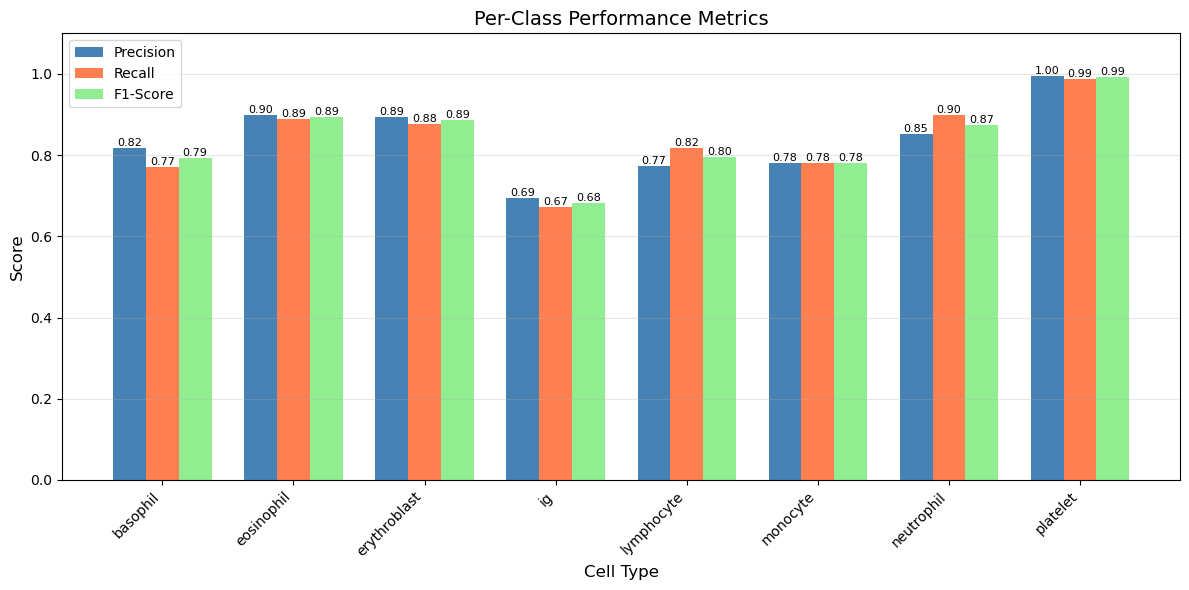

In [36]:
# Per-Class Metrics Bar Chart
# ============================================================================

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=range(len(label_names))
)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(label_names))  
width = 0.25  

bars1 = ax.bar(x - width, precision, width, label='Precision', color='steelblue')
bars2 = ax.bar(x, recall, width, label='Recall', color='coral')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='lightgreen')

ax.set_xlabel('Cell Type', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])  
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



In [ ]:
# Precision-Recall Curves
# ============================================================================

# Konvertiere y_test zu One-Hot-Encoding (für multi-class PR curves)
y_test_bin = label_binarize(y_test, classes=range(len(label_names)))

# Wahrscheinlichkeiten 
y_proba = best_model.predict_proba(X_test_scaled)

plt.figure(figsize=(12, 8))

# Für jede Klasse: Berechne Precision-Recall Curve
for class_idx, class_name in enumerate(label_names):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, class_idx],  # Wahre Labels (0 oder 1 für diese Klasse)
        y_proba[:, class_idx]       # Predicted Wahrscheinlichkeiten für diese Klasse
    )
    
    # Berechne AUC (Area Under Curve)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=f'{class_name} (AUC={pr_auc:.2f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves (per Class)', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
# plt.savefig('precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
print("- Kurve oben rechts = sehr gut (hohe Precision UND Recall)")
print("- AUC nahe 1.0 = perfekt, nahe 0.5 = schlecht")
print("- Kurven-Form zeigt Trade-off zwischen Precision/Recall")

In [ ]:
y_test_bin

In [ ]:
# ROC Curves 
# ============================================================================

# Konvertiere zu binär
y_test_bin = label_binarize(y_test, classes=range(len(label_names)))
y_proba = best_model.predict_proba(X_test_scaled)

# Erstelle Plot
plt.figure(figsize=(12, 8))

# Für jede Klasse
for class_idx, class_name in enumerate(label_names):
    # Berechne ROC
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], y_proba[:, class_idx])
    roc_auc = auc(fpr, tpr)
    
    # Plotte
    plt.plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc:.2f})', linewidth=2)

# Diagonale (= Random Classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (per Class)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
# plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Support vs. Performance
# ============================================================================

report_dict = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
train_support = [np.sum(y_train == i) for i in range(len(label_names))]
f1_scores = [report_dict[name]['f1-score'] for name in label_names]

plt.figure(figsize=(10, 6))
plt.scatter(train_support, f1_scores, s=150, alpha=0.6, color='steelblue', edgecolors='black')

for i, name in enumerate(label_names):
    plt.annotate(name, (train_support[i], f1_scores[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xlabel('Number of training samples', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Training Support vs. Performance', fontsize=14)
plt.grid(alpha=0.3)
plt.ylim([0, 1.1])

z = np.polyfit(train_support, f1_scores, 1)
p = np.poly1d(z)
plt.plot(train_support, p(train_support), "r--", alpha=0.5, label='Trend')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Class-Pair Confusion Heatmap
# ============================================================================

cm = confusion_matrix(y_test, y_pred)

confusion_symmetric = cm + cm.T 
np.fill_diagonal(confusion_symmetric, 0)  

confusion_symmetric_norm = confusion_symmetric / confusion_symmetric.max()

plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_symmetric,
    annot=True,
    fmt='d',
    cmap='Reds',  
    xticklabels=label_names,
    yticklabels=label_names,
    cbar_kws={'label': ' '}
)

plt.title('Class-Pair Confusion', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()